## Regresión Espacial

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from pysal.model import spreg
from pysal.lib import weights
from pysal.explore import esda
from scipy import stats
import statsmodels.formula.api as sm
import numpy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sbn

In [2]:

df = gpd.read_file('../data/regresion_POMCA_Final.geojson')

### A cada cuenca de nivel 10 se le debe asiganr un grupo de cuenca mayor del nivel 5

In [3]:
level5 = gpd.read_file('C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/shapes/HydroBasins/hybas_sa_lev04_v1c.shp')
level5 = level5.to_crs(df.crs)

# renombrar la columna HYBAS_ID a HYBAS_ID_lvl5 para evitar conflictos
level5 = level5.rename(columns={'HYBAS_ID': 'HYBAS_ID_lvl5'})
# Spatial join: asignar MAIN_BAS (nivel 5) como régimen a cada polígono de df (nivel 10)
df = gpd.sjoin(df, level5[['HYBAS_ID_lvl5', 'geometry']], how='left', predicate='intersects')
# Convertir a string para usar como régimen categórico en modelos
df['HYBAS_ID_lvl5'] = df['HYBAS_ID_lvl5'].astype(str)

In [4]:
import numpy as np

df['log_sp_density'] = df['sp_density'].apply(lambda x: 0 if x == 0 else np.log(x))
df['log_sp_density_std'] = df['sp_density_std'].apply(lambda x: 0 if x == 0 else np.log(x))

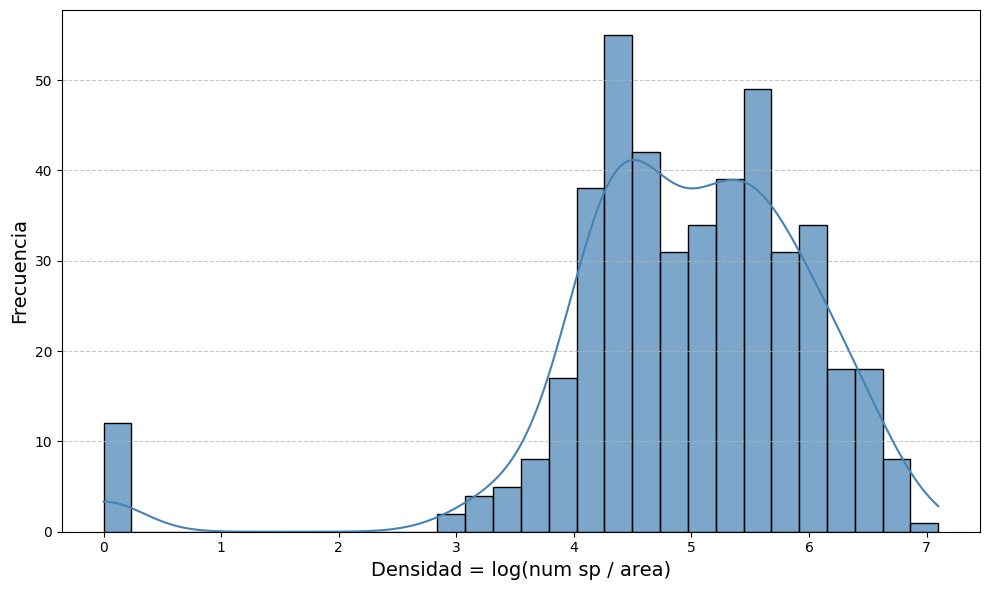

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Histograma con línea de densidad
sns.histplot(df['log_sp_density'], bins=30, kde=True, color='steelblue', edgecolor='black', alpha=0.7)

# Título y etiquetas
plt.title('', fontsize=16)
plt.xlabel('Densidad = log(num sp / area)', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)

# Rejilla
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar
plt.tight_layout()
plt.show()


In [6]:
variable_names = ['bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean',
       'bio12_mean', 'bio15_mean']
df[variable_names].corr()

,bio1_mean,bio3_mean,bio4_mean,bio7_mean,bio12_mean,bio15_mean
bio1_mean,1.000000,0.197671,0.035652,0.256734,0.388408,-0.073167
bio3_mean,0.197671,1.000000,-0.611460,-0.527476,0.417503,-0.810604
bio4_mean,0.035652,-0.611460,1.000000,0.364585,-0.121294,0.492487
bio7_mean,0.256734,-0.527476,0.364585,1.000000,-0.327693,0.318455
bio12_mean,0.388408,0.417503,-0.121294,-0.327693,1.000000,-0.177877
bio15_mean,-0.073167,-0.810604,0.492487,0.318455,-0.177877,1.000000


In [8]:
print(df.shape)
df.columns

(293, 21)


Index(['HYBAS_ID', 'MAIN_BAS', 'num_species', 'num_points', 'bio1_mean',
       'bio3_mean', 'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean',
       'elevacion', 'sp_density', 'num_species_std', 'w_num_species_std',
       'num_points_std', 'w_num_points_std', 'sp_density_std',
       'w_sp_density_std', 'geometry', 'log_sp_density', 'log_sp_density_std'],
      dtype='object')

In [7]:
# Probamos el primer modelo de regresión lineal
variable_names = ['bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean',
       'bio12_mean', 'bio15_mean','elevacion']


m1 = spreg.OLS(df[['log_sp_density']].values, 
               df[variable_names].values, 
               name_y='log_species_density', 
               name_x=variable_names)



In [83]:
print(m1.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log_species_density                Number of Observations:         293
Mean dependent var  :      4.8783                Number of Variables   :           8
S.D. dependent var  :      1.1985                Degrees of Freedom    :         285
R-squared           :      0.3257
Adjusted R-squared  :      0.3091
Sum squared residual:     282.826                F-statistic           :     19.6642
Sigma-square        :       0.992                Prob(F-statistic)     :   1.937e-21
S.E. of regression  :       0.996                Log likelihood        :    -410.572
Sigma-square ML     :       0.965                Akaike info criterion :     837.143
S.E of regression ML:      0.9825                Schwarz criterion     :     866.584

-----------------------------------------------------

In [8]:
m0=sm.ols("log_sp_density ~ bio1_mean + bio3_mean + bio4_mean + bio7_mean + bio12_mean + bio15_mean + elevacion", data=df).fit()

In [9]:
print(m0.summary())

                            OLS Regression Results                            
Dep. Variable:         log_sp_density   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     33.73
Date:               lun, 21 jul. 2025   Prob (F-statistic):           1.59e-37
Time:                        22:41:07   Log-Likelihood:                -599.53
No. Observations:                 446   AIC:                             1215.
Df Residuals:                     438   BIC:                             1248.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.4786      3.551      2.387      0.0

Evaluamos los residuales por una variable de categoría

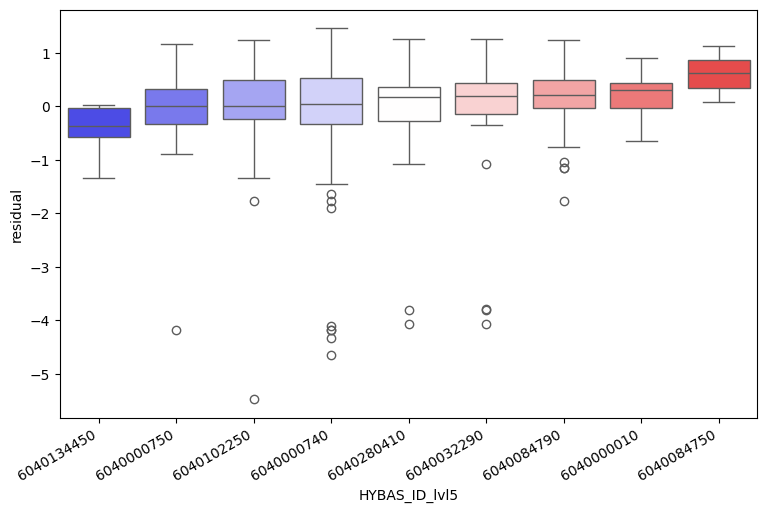

In [10]:
df['residual'] = m1.u
medians = df.groupby("HYBAS_ID_lvl5").residual.median().to_frame('basin_residual')

f = plt.figure(figsize=(9,6))
ax = plt.gca()
sbn.boxplot(x='HYBAS_ID_lvl5', y='residual', ax = ax,
                data=df.merge(medians, how='left',left_on='HYBAS_ID_lvl5',right_index=True).sort_values('basin_residual'), palette='bwr',  dodge=False)
f.autofmt_xdate()
plt.show()

Espacial lag de los residuales

In [11]:
# df_geo = gpd.GeoDataFrame(df, geometry='centroid')
knn = weights.KNN.from_dataframe(df, k=5)

ValueError: axis 0 index 445 exceeds matrix dimension 293

In [12]:
lag_residual = weights.spatial_lag.lag_spatial(knn, m1.u) # se obtiene la columna spatial_lag de la matris denominada Weights y se le calcula el espacial lag con la matriz de KNN
ax = sbn.regplot(x=m1.u.flatten(), y=lag_residual.flatten(),line_kws=dict(color='orangered'),ci=None)
ax.set_xlabel('Model Residuals - $u$')
ax.set_ylabel('Spatial Lag of Model Residuals - $W u$');

NameError: name 'knn' is not defined

## Efectos de autocorrelación exógena entre las variables predictoras

In [18]:
%matplotlib inline

from pysal.model import spreg
from pysal.lib import weights
from pysal.explore import esda
from scipy import stats
import statsmodels.formula.api as sm
import numpy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sbn

In [19]:
variable_names = ['bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean',
       'bio12_mean', 'bio15_mean','elevacion']
knn = weights.KNN.from_dataframe(df, k=7)

In [20]:
df2 = df.copy()

In [21]:
for var in variable_names:
    df2['pg_' + var] = df2[var]

In [22]:
wx = df2.filter(like='pg')\
        .apply(lambda y: weights.spatial_lag.lag_spatial(knn, y))\
        .rename(columns=lambda c: 'w_' + c)

In [23]:
slx_exog = df2[variable_names].join(wx)
m5 = spreg.OLS(
    df2[['log_sp_density']].values,      
    slx_exog.values,                     
    name_y='log_sp_density',
    name_x=slx_exog.columns.tolist()
)


print(m5.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log_sp_density                Number of Observations:         293
Mean dependent var  :      4.8783                Number of Variables   :          15
S.D. dependent var  :      1.1985                Degrees of Freedom    :         278
R-squared           :      0.3733
Adjusted R-squared  :      0.3417
Sum squared residual:      262.86                F-statistic           :     11.8274
Sigma-square        :       0.946                Prob(F-statistic)     :     2.1e-21
S.E. of regression  :       0.972                Log likelihood        :    -399.846
Sigma-square ML     :       0.897                Akaike info criterion :     829.692
S.E of regression ML:      0.9472                Schwarz criterion     :     884.895

----------------------------------------------------------

### Efectos de autocorrelación endógena con el error espacial

In [24]:
m6 = spreg.GM_Error_Het(df[['log_sp_density']].values, 
                        df[variable_names].values,                        
                        w=knn, 
                        name_y='log_sp_density', 
                        name_x=variable_names)


print(m6.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :log_sp_density                Number of Observations:         293
Mean dependent var  :      4.8783                Number of Variables   :           8
S.D. dependent var  :      1.1985                Degrees of Freedom    :         285
Pseudo R-squared    :      0.3227
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         6.00577         4.83607         1.24187         0.21428
           bio1_mean         0.42678         0.18376  

### Efectos de autocorrelación endógena con la variable dependiente

In [25]:
m7 = spreg.GM_Lag(df[['log_sp_density']].values, 
                  df[variable_names].values, 
                  w=knn, 
                  name_y='log_sp_density', 
                  name_x=variable_names)


print(m7.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :log_sp_density                Number of Observations:         293
Mean dependent var  :      4.8783                Number of Variables   :           9
S.D. dependent var  :      1.1985                Degrees of Freedom    :         284
Pseudo R-squared    :      0.3827
Spatial Pseudo R-squared:  0.2504

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        -3.00283         5.22273        -0.57495         0.56532
           bio1_mean         0.18246         0.18017         1.01273         0.31119
           bio3_mean        -0.02241    

## Ejemplo con cuencas

In [26]:
# Cargar datos
gdf = df.copy()

In [27]:
gdf.columns

Index(['HYBAS_ID', 'MAIN_BAS', 'num_species', 'num_points', 'bio1_mean',
       'bio3_mean', 'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean',
       'elevacion', 'sp_density', 'num_species_std', 'w_num_species_std',
       'num_points_std', 'w_num_points_std', 'sp_density_std',
       'w_sp_density_std', 'geometry', 'log_sp_density', 'log_sp_density_std',
       'residual'],
      dtype='object')

In [29]:
import geopandas as gpd
import numpy as np
import libpysal
from libpysal.weights import Queen
from sklearn.preprocessing import StandardScaler
import spreg

# Definir las variables dependiente e independientes
y = gdf['log_sp_density'].values.reshape((-1, 1))
independent_vars = ['bio1_mean', 'bio3_mean', 'bio4_mean', 'bio7_mean',
       'bio12_mean', 'bio15_mean','elevacion']
X = gdf[independent_vars].values

# Escalar las variables independientes
st = StandardScaler()
X_scaled = st.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=independent_vars)

# Crear la matriz de pesos espaciales por contigüidad tipo Queen
w = knn

# Calcular la autocorrelación exógena de las variables independientes escaladas
wx_dict = {}
for var in independent_vars:
    wx_dict[f'w_{var}'] = libpysal.weights.spatial_lag.lag_spatial(w, X_scaled_df[var])

wx_df = pd.DataFrame(wx_dict)

# Combinar las variables independientes originales escaladas con sus versiones espacialmente rezagadas
slx_exog = pd.concat([X_scaled_df, wx_df], axis=1)

# Ajustar el modelo OLS con las variables exógenas espacialmente rezagadas (SLX)
ols_model_slx = spreg.OLS(gdf['log_sp_density'].values.reshape((-1, 1)),
                          slx_exog.values,
                          name_y='log_sp_density',
                          name_x=slx_exog.columns.tolist(),
                          name_w='queen_contiguity')

# Imprimir el resumen del modelo OLS con SLX
print(ols_model_slx.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log_sp_density                Number of Observations:         293
Mean dependent var  :      4.8783                Number of Variables   :          15
S.D. dependent var  :      1.1985                Degrees of Freedom    :         278
R-squared           :      0.3733
Adjusted R-squared  :      0.3417
Sum squared residual:      262.86                F-statistic           :     11.8274
Sigma-square        :       0.946                Prob(F-statistic)     :     2.1e-21
S.E. of regression  :       0.972                Log likelihood        :    -399.846
Sigma-square ML     :       0.897                Akaike info criterion :     829.692
S.E of regression ML:      0.9472                Schwarz criterion     :     884.895

----------------------------------------------------------

### Modelo resagando el error

In [30]:
# Ajustar el modelo de error espacial (GM_Error_Het)
spt_error = spreg.GM_Error_Het(y, X_scaled, w=w,
                                        name_y='log_sp_density',
                                      name_x=independent_vars,
                                      name_w='knn_weights')

# Imprimir el resumen del modelo de error espacial
print(spt_error.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------
Data set            :     unknown
Weights matrix      : knn_weights
Dependent Variable  :log_sp_density                Number of Observations:         293
Mean dependent var  :      4.8783                Number of Variables   :           8
S.D. dependent var  :      1.1985                Degrees of Freedom    :         285
Pseudo R-squared    :      0.3227
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         4.86274         0.08912        54.56330         0.00000
           bio1_mean         1.30947         0.56383  

### Modelo con retardo espacial

In [31]:
# Ajustar el modelo de retardo espacial (GM_Lag)
spatial_lag_model = spreg.GM_Lag(y, X_scaled, w=w,
                                name_y='log_sp_density',
                                name_x=independent_vars,
                                name_w='knn_weights')

# Imprimir el resumen del modelo de retardo espacial
print(spatial_lag_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      : knn_weights
Dependent Variable  :log_sp_density                Number of Observations:         293
Mean dependent var  :      4.8783                Number of Variables   :           9
S.D. dependent var  :      1.1985                Degrees of Freedom    :         284
Pseudo R-squared    :      0.3827
Spatial Pseudo R-squared:  0.2504

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.89380         1.19920         0.74533         0.45607
           bio1_mean         0.55984         0.55280         1.01273         0.31119
           bio3_mean        -0.12579    

## Modelos de Regresión para Heterogeneidad Espacial

In [84]:
%matplotlib inline

from pysal.model import spreg
from pysal.lib import weights
from pysal.explore import esda
from scipy import stats
import statsmodels.formula.api as sm
import numpy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sbn

### A cada cuenca de nivel 10 se le debe asiganr un grupo de cuenca mayor del nivel 5

In [ ]:
level5 = gpd.read_file('C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/shapes/HydroBasins/hybas_sa_lev04_v1c.shp')
level5 = level5.to_crs(df.crs)

# renombrar la columna HYBAS_ID a HYBAS_ID_lvl5 para evitar conflictos
level5 = level5.rename(columns={'HYBAS_ID': 'HYBAS_ID_lvl5'})
# Spatial join: asignar MAIN_BAS (nivel 5) como régimen a cada polígono de df (nivel 10)
df = gpd.sjoin(df, level5[['HYBAS_ID_lvl5', 'geometry']], how='left', predicate='intersects')
# Convertir a string para usar como régimen categórico en modelos
df['HYBAS_ID_lvl5'] = df['HYBAS_ID_lvl5'].astype(str)

In [90]:
# renombrar la columna HYBAS_ID a HYBAS_ID_lvl5 para evitar conflictos
level5 = level5.rename(columns={'HYBAS_ID': 'HYBAS_ID_lvl5'})
# Spatial join: asignar MAIN_BAS (nivel 5) como régimen a cada polígono de df (nivel 10)
df = gpd.sjoin(df, level5[['HYBAS_ID_lvl5', 'geometry']], how='left', predicate='intersects')
# Convertir a string para usar como régimen categórico en modelos
df['HYBAS_ID_lvl5'] = df['HYBAS_ID_lvl5'].astype(str)

ValueError: 'index_right' cannot be a column name in the frames being joined

In [100]:
print(df['HYBAS_ID_lvl5'].value_counts())

HYBAS_ID_lvl5
6040000740    231
6040102250     76
6040032290     35
6040000750     31
6040084790     29
6040280410     21
6040000010     12
6040134450      8
6040084750      3
Name: count, dtype: int64


In [102]:
# eliminar entradas con este regime HYBAS_ID_lvl5 = 6040084750
df = df[df['HYBAS_ID_lvl5'] != '6040084750'].copy()

In [103]:
print(df['HYBAS_ID_lvl5'].value_counts())

HYBAS_ID_lvl5
6040000740    231
6040102250     76
6040032290     35
6040000750     31
6040084790     29
6040280410     21
6040000010     12
6040134450      8
Name: count, dtype: int64


In [ ]:
counts = df['HYBAS_ID_lvl5'].value_counts()
df['MAIN_BAS_GROUP'] = df['HYBAS_ID_lvl5'].apply(lambda x: x if counts[x] >= 5 else 'UNION')


In [60]:
df['MAIN_BAS_GROUP'].value_counts()
df['MAIN_BAS_GROUP'] = df['MAIN_BAS_GROUP'].astype(str)

In [104]:
m3=sm.ols("log_sp_density ~ bio1_mean + bio3_mean + bio4_mean + bio7_mean + bio12_mean + bio15_mean + elevacion + HYBAS_ID_lvl5", data=df).fit()
print(m3.summary2())

                      Results: Ordinary least squares
Model:                 OLS                 Adj. R-squared:        0.342    
Dependent Variable:    log_sp_density      AIC:                   1215.4640
Date:                  2025-07-21 22:30    BIC:                   1276.8676
No. Observations:      443                 Log-Likelihood:        -592.73  
Df Model:              14                  F-statistic:           17.37    
Df Residuals:          428                 Prob (F-statistic):    5.27e-34 
R-squared:             0.362               Scale:                 0.88035  
---------------------------------------------------------------------------
                             Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    9.0538   3.9487  2.2928 0.0223  1.2925 16.8151
HYBAS_ID_lvl5[T.6040000740] -0.2397   0.3103 -0.7725 0.4402 -0.8496  0.3702
HYBAS_ID_lvl5[T.6040000750] -0.398

### Intercepto variable

In [105]:
# PySAL implementation
m4 = spreg.OLS_Regimes(df[['log_sp_density']].values, df[variable_names].values,
                       df['HYBAS_ID_lvl5'].tolist(),
                       constant_regi='many', cols2regi=[False]*len(variable_names),
                       regime_err_sep=False,
                       name_y='log_sp_density', name_x=variable_names)
print(m4.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES - REGIMES
---------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log_sp_density                Number of Observations:         443
Mean dependent var  :      4.9307                Number of Variables   :          14
S.D. dependent var  :      1.1563                Degrees of Freedom    :         429
R-squared           :      0.3482
Adjusted R-squared  :      0.3285
Sum squared residual:     385.145                F-statistic           :     17.6310
Sigma-square        :       0.898                Prob(F-statistic)     :   1.058e-32
S.E. of regression  :       0.948                Log likelihood        :    -597.591
Sigma-square ML     :       0.869                Akaike info criterion :    1223.182
S.E of regression ML:      0.9324                Schwarz criterion     :    1280.492

--------------------------------------

### Intercepto y coeficientes variables

In [106]:
# df_reg = df[df['NOMAH'].isin(['Magdalena Cauca', 'Orinoco', 'Pacifico', 'Caribe'])].copy()
m4 = spreg.OLS_Regimes(df[['log_sp_density']].values, df[variable_names].values,
                          df['HYBAS_ID_lvl5'].tolist(),
                          constant_regi='many',
                          regime_err_sep=False,
                          name_y='log_sp_density', name_x=variable_names)
print(m4.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES - REGIMES
---------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :log_sp_density                Number of Observations:         443
Mean dependent var  :      4.9307                Number of Variables   :          56
S.D. dependent var  :      1.1563                Degrees of Freedom    :         387
R-squared           :      0.4209
Adjusted R-squared  :      0.3386
Sum squared residual:     342.214                F-statistic           :      5.1137
Sigma-square        :       0.884                Prob(F-statistic)     :   1.929e-22
S.E. of regression  :       0.940                Log likelihood        :    -571.413
Sigma-square ML     :       0.772                Akaike info criterion :    1254.827
S.E of regression ML:      0.8789                Schwarz criterion     :    1484.066

--------------------------------------

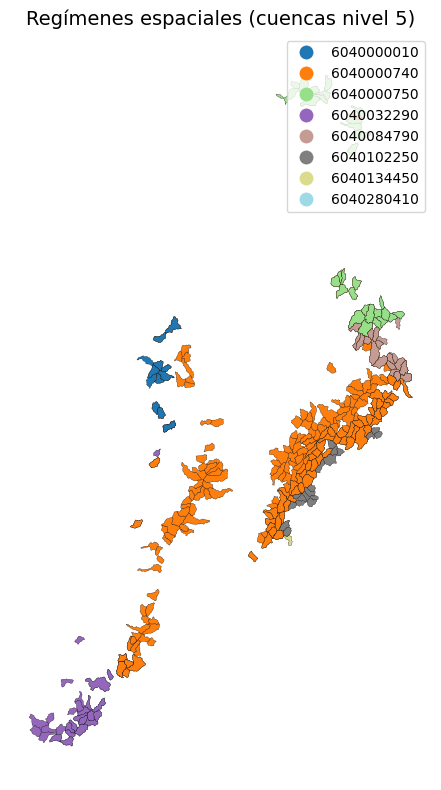

In [107]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Mapa de cuencas nivel 10, coloreadas por régimen (nivel 5)
df.plot(
    column='HYBAS_ID_lvl5',
    ax=ax,
    cmap='tab20',        # paleta de colores categóricos
    legend=True,
    edgecolor='black',
    linewidth=0.2
)

ax.set_title("Regímenes espaciales (cuencas nivel 5)", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()
